<a href="https://colab.research.google.com/github/nkocjan/computational-intelligence-methods/blob/dev/lab03/lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Zadanie 3**

Wymagane importy

In [58]:
#Wymagane importy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.datasets import load_diabetes
from sklearn.metrics import confusion_matrix
import time
import random
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
import math

Wczytanie danych z pliku

In [76]:
data = pd.read_csv("Advertising.csv", index_col=0)
X = data.iloc[:,:-1]
y = data.iloc[:, -1]

Plik advertising.csv zawiera w każdym rzędzie informację na temat wydatków na reklamę telewizyjną, reklamową i prasową dla pojedynczego produktu oraz zyski z jego sprzedaży. Można przedstawić zyski jako funkcję  Z(wTV,wradio,wprasa) . Proszę zaproponować architrekturę sieci neuronowej, która dokona aproksymacji tej funkcji i dokonać ewaluacji tej sieci. Proszę porównać wyniki (MSE) dla przynajmniej dwóch różnych struktur jeżeli chodzi o liczbę neuronów i dla dwóch różnych funkcji aktywacji (najlepiej relu i tanh). Proszę pamiętać o podzieleniu zbioru na dane uczące i testujące i o pilnowaniu skali danych.

In [77]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = ~((X < lower_bound) | (X > upper_bound)).any(axis=1)
X = X[mask]
y = y[mask]

print(f"Usunięto {data.shape[0] - X.shape[0]} wartości odstających")

Usunięto 2 wartości odstających


In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [79]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X = scaler.transform(X)

Dane przeskalowano

In [80]:
architektury = [(80, 80, 80, 80, 80), (100,100,100), (10,10,10)]
f_aktywacji = ["relu", "tanh"]

for arch in architektury:
  for f in f_aktywacji:
    model = MLPRegressor(solver='adam',hidden_layer_sizes=arch, max_iter = 1000, tol = 0.001, activation = f)
    model.fit(X_train, y_train)

    y_predict =  model.predict(X_test)
    print(f"Model: {arch}, f aktywacji: {f}")
    print(f"Model R^2 score : {model.score(X_train, y_train)}")
    print(f"Model MSE score : {mean_squared_error(y_test, y_predict)} \n")


Model: (80, 80, 80, 80, 80), f aktywacji: relu
Model R^2 score : 0.5415740557217079
Model MSE score : 11.731914318351285 

Model: (80, 80, 80, 80, 80), f aktywacji: tanh
Model R^2 score : 0.003939983748050602
Model MSE score : 27.268813058577553 

Model: (100, 100, 100), f aktywacji: relu
Model R^2 score : 0.5447696317369799
Model MSE score : 11.63556000830489 

Model: (100, 100, 100), f aktywacji: tanh
Model R^2 score : 0.9831077975820958
Model MSE score : 0.34264757248262406 

Model: (10, 10, 10), f aktywacji: relu
Model R^2 score : 0.8290122450707706
Model MSE score : 4.463355895924943 

Model: (10, 10, 10), f aktywacji: tanh
Model R^2 score : -0.23680949234231474
Model MSE score : 36.71865244100176 



**Zadanie 2**

Dużo zależy od learning rate - dobre do analizy

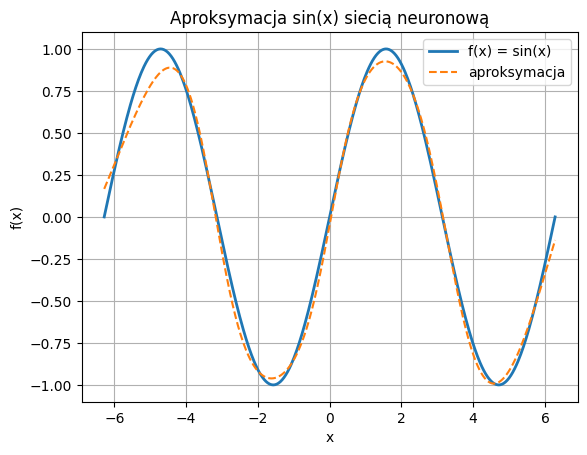

In [82]:
X = np.linspace(-2 * np.pi, 2 * np.pi, 500).reshape(-1, 1)
y = np.sin(X).ravel()
model = MLPRegressor(hidden_layer_sizes=(5), activation='tanh', max_iter=5000, random_state=0, learning_rate_init=0.1)
model.fit(X, y)
y_pred = model.predict(X)

plt.plot(X, y, label='f(x) = sin(x)', linewidth=2)
plt.plot(X, y_pred, label='aproksymacja', linestyle='--')
plt.legend()
plt.title("Aproksymacja sin(x) siecią neuronową")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

weights = model.coefs_
biases = model.intercepts_

!!!!!!!!!!!!!!!!!Dodać wzór funkcji aproksymującej

**Zadanie 3**

In [67]:
diabetes = load_diabetes()

In [71]:
X, y = diabetes.data, diabetes.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=0)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X = scaler.transform(X)

Architektury:

Dorobić funkcję do analizy, potem pet;a

In [ ]:
def calculate_mse(y_test, y_pred, model):
    return np.mean((y_true - y_pred) ** 2)

In [ ]:
architektury = [(5, 5), (25, 25, 25), (100, 100, 100, 100), (200, 200, 200, 200, 200)]

In [ ]:
for arch in architektury:
  model = MLPRegressor(hidden_layer_sizes=architektury, activation='tanh', max_iter=5000, random_state=0)
  model.fit(X, y)
  y_pred = model.predict(X_test)
  calculate_mse(y_test, y_pred, model)

